In [ ]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.interpolate import splrep, splev
from statsmodels.nonparametric.smoothers_lowess import lowess


def adjust_the_line(red_cell, green_cell):
    new_red_value = interplote_data(red_cell, 1000)

    average = lowess_smooth(new_red_value)

    baseline_average = find_baseline(average)
    mini_crop, max_crop = find_crops(average, baseline_average)
    data_new = average[mini_crop:max_crop]

    x = np.linspace(0, 1, len(data_new))
    y = data_new
    spl = splrep(x, y)
    new_x = np.linspace(x.min(), x.max(), 1000)
    new_red_y = splev(new_x, spl)

    new_green_value = interplote_data(green_cell, 1000)

    smooth_green = lowess_smooth(new_green_value)
    data_new_green = smooth_green[mini_crop:max_crop]

    x = np.linspace(0, 1, len(data_new_green))
    y = data_new_green
    spl = splrep(x, y)
    new_x = np.linspace(x.min(), x.max(), 1000)
    new_green_y = splev(new_x, spl)

    return new_red_y, new_green_y


def interplote_data(data, num):
    x = np.linspace(0, 1, len(data))
    spl = splrep(x, data)
    new_x = np.linspace(0, 1, num)
    new_value = splev(new_x, spl)

    return new_value


def find_baseline(data):
    n = len(data)

    start_index = int(n * 0.30)
    end_index = int(n * 0.70)
    middle_40_percent = data[start_index:end_index]

    min_value = min(middle_40_percent)

    min_indices_relative = [
        i
        for i, value in enumerate(middle_40_percent)
        if value == min_value
    ]

    min_indices_absolute = (
        start_index + min_indices_relative[0]
    )

    baseline_value = data[
        min_indices_absolute - int(n * 0.005):
        min_indices_absolute + int(n * 0.005)
    ]

    baseline_average = np.mean(baseline_value)

    return baseline_average


def find_crops(data, target_value):
    data_as_int = [int(float(x)) for x in data]

    matching_indices = [
        i
        for i, value in enumerate(data_as_int)
        if value < target_value
    ]

    mini_crop = 0
    max_crop = len(data)

    if 0 in matching_indices:
        i = 0

        while i in range(0, len(matching_indices)):
            if 0 < (
                matching_indices[i + 1]
                - matching_indices[i]
            ) <= 2:
                mini_crop = matching_indices[i + 1]
                i += 1
            else:
                break

    reverse_matching_indices = matching_indices[::-1]

    if (len(data) - 1) in reverse_matching_indices:
        i = 0

        while i in range(
            0,
            len(reverse_matching_indices)
        ):
            if 0 < (
                reverse_matching_indices[i]
                - reverse_matching_indices[i + 1]
            ) <= 2:
                max_crop = reverse_matching_indices[i + 1]
                i += 1
            else:
                break

    return mini_crop, max_crop


def normalize_data(data):
    data_max = max(data)

    normalized_data_1d = [
        value / data_max
        for value in data
    ]

    return normalized_data_1d


def lowess_smooth(data):
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.05
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:, 1]


def interpolate_data_b(x, y, num):
    spl = splrep(x, y)
    new_x = np.linspace(min(x), max(x), num)
    new_value = splev(new_x, spl)

    return new_value


def half_data(data, num):
    num_r = math.ceil(num / 2)

    front_half = data[:num_r]
    back_half = data[num_r:]

    front_half_reversed = front_half[::-1]

    return front_half_reversed, back_half


def ave_center_data(data):
    n = len(data)

    start = int(n * 0.495)
    end = int(n * 0.595)

    middle_1_percent = data[start:end]

    baseline = (
        sum(middle_1_percent)
        / len(middle_1_percent)
    )

    return baseline


def fraction(data):
    total_sum = sum(data)

    cumulative_sum = []
    current_sum = 0

    for value in data:
        current_sum += value
        cumulative_sum.append(current_sum)

    cumulative_weights = [
        cumulative_value / total_sum
        for cumulative_value in cumulative_sum
    ]

    return cumulative_weights


def figure_3_create(new_red, new_green):
    front_green, back_green = half_data(
        new_green,
        len(new_green)
    )

    x_front = fraction(front_green)
    x_back = fraction(back_green)

    front_red, back_red = half_data(
        new_red,
        len(new_red)
    )

    intensity_front = interpolate_data_b(
        x_front,
        front_red,
        10000
    )
    intensity_front = normalize_data(intensity_front)

    intensity_back = interpolate_data_b(
        x_back,
        back_red,
        10000
    )
    intensity_back = normalize_data(intensity_back)

    return intensity_front, intensity_back


def fig_4_create(new_red, new_green):
    front_green, back_green = half_data(
        new_green,
        len(new_green)
    )

    x_front = fraction(front_green)
    x_back = fraction(back_green)

    baseline = ave_center_data(new_red)

    front_red, back_red = half_data(
        new_red,
        len(new_red)
    )

    front_red_b = [
        (value / baseline) - 1
        for value in front_red
    ]

    back_red_b = [
        (value / baseline) - 1
        for value in back_red
    ]

    intensity_front = interpolate_data_b(
        x_front,
        front_red_b,
        1000
    )

    intensity_back = interpolate_data_b(
        x_back,
        back_red_b,
        1000
    )

    return intensity_front, intensity_back


def calculate_plot_parameter(intensities):
    average = np.mean(intensities, axis=0)
    average = lowess_smooth(average)

    stderr = (
        np.std(intensities, axis=0)
        / np.sqrt(len(intensities))
    )
    stderr = lowess_smooth(stderr)

    std = np.std(intensities, axis=0)
    std = lowess_smooth(std)

    return average, stderr, std


def allinfunction(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]


    red_values_list = []
    green_values_list = []
    fig_3_intensities = []
    fig_4_intensities = []

    for file in csv_files: 
        try:
            df = pd.read_csv(os.path.join(folder_path, file))
            red_cell = df.iloc[:, 2].tolist() 
            green_cell = df.iloc[:, 1].tolist() 
            new_green_1, new_red_1 = adjust_the_line (green_cell, red_cell)

            new_green = [(i-100) for i in new_green_1]
            new_red = [(i-100) for i in new_red_1]

            # This is figure 1 & 2 parts
            normalized_red_value = normalize_data(new_red)
            normalized_green_value = normalize_data(new_green)
            red_values_list.append(normalized_red_value)
            green_values_list.append(normalized_green_value)

            # This is figure 3 part
            intensity_front_3, intensity_back_3 = figure_3_create(new_red,new_green)
            fig_3_intensities.append(intensity_front_3)
            fig_3_intensities.append(intensity_back_3)

            # This is figure 4 part
            intensity_front_4, intensity_back_4 = fig_4_create (new_red,new_green)
            averaged_list = [(a + b) / 2 for a, b in zip(intensity_front_4, intensity_back_4)]
            fig_4_intensities.append(averaged_list)

        except:
            continue

    return red_values_list, green_values_list, fig_3_intensities, fig_4_intensities

## CytoSense-mTORC1/S6K (mutation) control

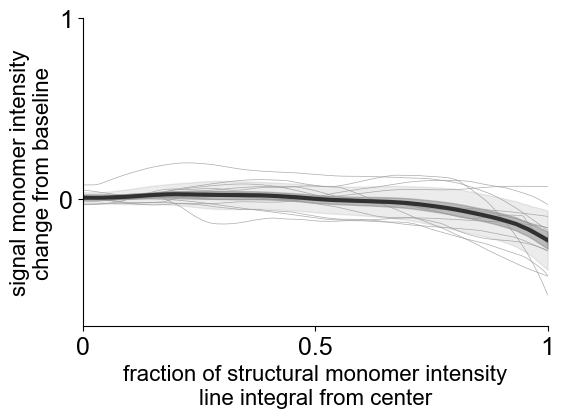

In [ ]:
def plot_4(intensities, average, stderr, std):  
    plt.figure(figsize=(6, 4))

    for data in intensities:
        plt.plot(data, color="#969696", alpha=0.8, linewidth=0.5)

    plt.plot(average, color='#313131', linewidth=3, label='Average')

    plt.fill_between(range(len(average)), average - stderr, average + stderr,
                     color='gray', alpha=0.45)
    plt.fill_between(range(len(average)), average - std, average + std,
                     color='gray', alpha=0.15)

    plt.xticks([0, len(average)//2, len(average)-1], [0, 0.5, 1],
               fontsize=18, fontname='Arial')
    plt.yticks([0, 1], fontsize=18, fontname='Arial')

    plt.xlim(0, len(average)-1)
    plt.ylim(-0.7, 1)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("fraction of structural monomer intensity\nline integral from center",
               fontsize=16, fontname='Arial')
    plt.ylabel("signal monomer intensity\nchange from baseline",
               fontsize=16, fontname='Arial')

    plt.show()

file_path = r"degron mutation\mutation control"

red_values_list, green_values_list, fig_3_intensities, fig_4_intensities = allinfunction(file_path)

average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

## CytoSense-mTORC1/S6K (mutation) drug

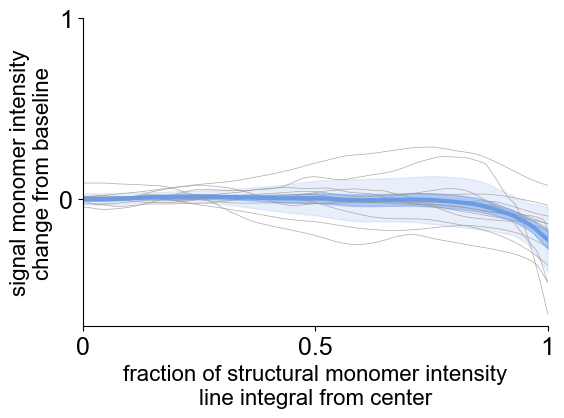

In [ ]:
def plot_4(intensities, average, stderr, std):  
    plt.figure(figsize=(6, 4))

    for data in intensities:
        plt.plot(data, color="#969696", alpha=0.8, linewidth=0.5)

    plt.plot(average, color='#6b9ae7', linewidth=3, label='Average')

    plt.fill_between(range(len(average)), average - stderr, average + stderr,
                     color='#6b9ae7', alpha=0.45)
    plt.fill_between(range(len(average)), average - std, average + std,
                     color='#6b9ae7', alpha=0.15)

    plt.xticks([0, len(average)//2, len(average)-1], [0, 0.5, 1],
               fontsize=18, fontname='Arial')
    plt.yticks([0, 1], fontsize=18, fontname='Arial')

    plt.xlim(0, len(average)-1)
    plt.ylim(-0.7, 1)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("fraction of structural monomer intensity\nline integral from center",
               fontsize=16, fontname='Arial')
    plt.ylabel("signal monomer intensity\nchange from baseline",
               fontsize=16, fontname='Arial')

    plt.show()

file_path = r"degron mutation\mutation drug"

red_values_list, green_values_list, fig_3_intensities, fig_4_intensities = allinfunction(file_path)

average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

## CytoSense-mTORC1/S6K (WT) control

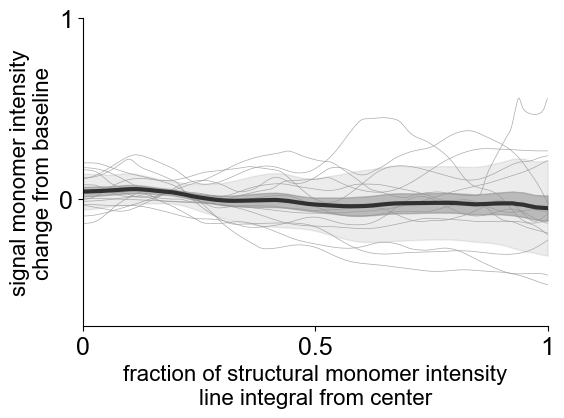

In [ ]:

def plot_4(intensities, average, stderr, std):  
    plt.figure(figsize=(6, 4))

    for data in intensities:
        plt.plot(data, color="#969696", alpha=0.8, linewidth=0.5)

    plt.plot(average, color='#313131', linewidth=3, label='Average')

    plt.fill_between(range(len(average)), average - stderr, average + stderr,
                     color='gray', alpha=0.45)
    plt.fill_between(range(len(average)), average - std, average + std,
                     color='gray', alpha=0.15)

    plt.xticks([0, len(average)//2, len(average)-1], [0, 0.5, 1],
               fontsize=18, fontname='Arial')
    plt.yticks([0, 1], fontsize=18, fontname='Arial')

    plt.xlim(0, len(average)-1)
    plt.ylim(-0.7, 1)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("fraction of structural monomer intensity\nline integral from center",
               fontsize=16, fontname='Arial')
    plt.ylabel("signal monomer intensity\nchange from baseline",
               fontsize=16, fontname='Arial')

    plt.show()

file_path = r"degron mutation\WT control"
red_values_list, green_values_list, fig_3_intensities, fig_4_intensities = allinfunction(file_path)

average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

## CytoSense-mTORC1/S6K (WT) drug

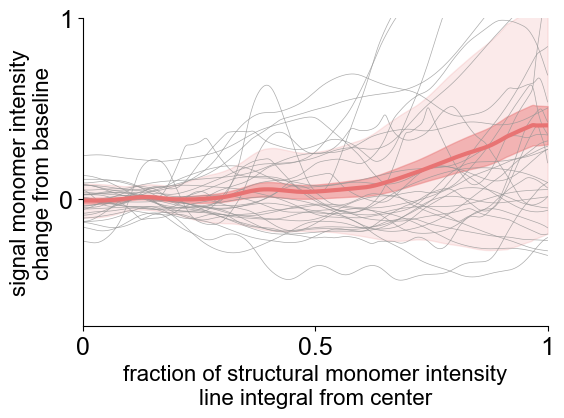

In [ ]:
def plot_4(intensities, average, stderr, std):  
    plt.figure(figsize=(6, 4))

    for data in intensities:
        plt.plot(data, color="#969696", alpha=0.8, linewidth=0.5)

    plt.plot(average, color='#E87373', linewidth=3, label='Average')

    plt.fill_between(range(len(average)), average - stderr, average + stderr,
                     color='#E87373', alpha=0.45)
    plt.fill_between(range(len(average)), average - std, average + std,
                     color='#E87373', alpha=0.15)

    plt.xticks([0, len(average)//2, len(average)-1], [0, 0.5, 1],
               fontsize=18, fontname='Arial')
    plt.yticks([0, 1], fontsize=18, fontname='Arial')

    plt.xlim(0, len(average)-1)
    plt.ylim(-0.7, 1)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("fraction of structural monomer intensity\nline integral from center",
               fontsize=16, fontname='Arial')
    plt.ylabel("signal monomer intensity\nchange from baseline",
               fontsize=16, fontname='Arial')

    plt.show()

file_path = r"degron mutation\WT drug"

red_values_list, green_values_list, fig_3_intensities, fig_4_intensities = allinfunction(file_path)

average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

# Figure S3F and S3G

In [7]:
def allinfunction_raw_rignal(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]


    red_values_list = []
    for file in csv_files: # range(0,len(df['Red_intensity']))
        try:
            df = pd.read_csv(os.path.join(folder_path, file))
            red_cell = df.iloc[:, 2].tolist() 
            green_cell = df.iloc[:, 1].tolist() 
            new_green, new_red = adjust_the_line (green_cell, red_cell)

            # This is figure 1 & 2 parts
            new_red_substract = [i-102 for i in new_red]
            red_values_list.append(new_red_substract)

        except Exception as e:
            print('error in {}'.format(file))

    return red_values_list

In [ ]:
file_path = r"degron mutation\WT control"
red_values_list_control = allinfunction_raw_rignal(file_path)
average_con, stderr_con, std_con = calculate_plot_parameter(red_values_list_control)

file_path = r"degron mutation\WT drug"
red_values_list_drug = allinfunction_raw_rignal(file_path)
average_drug, stderr_drug, std_drug = calculate_plot_parameter(red_values_list_drug)



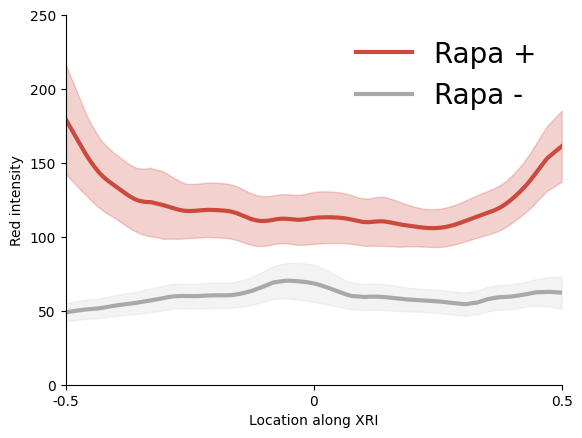

In [ ]:
average = average_drug
red = '#cc493e'
blue = '#6b9ae7'

plt.plot(average_drug, color=red, linewidth=3, label='Rapa +')
plt.fill_between(range(len(average_drug)), average_drug - stderr_drug, average_drug + stderr_drug, color=red, alpha=0.25)

plt.plot(average_con, color='darkgray', linewidth=3, label='Rapa -')
plt.fill_between(range(len(average_con)), average_con - stderr_con, average_con + stderr_con, color='lightgrey', alpha=0.25)


plt.xticks([0, len(average)//2, len(average)-1], [-0.5, 0, 0.5])

plt.xlim(0, len(average)-1)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ylim(0, 250)

plt.xlabel("Location along XRI")
plt.ylabel("Red intensity")

plt.legend(frameon=False, fontsize=20)

plt.show()

In [ ]:
file_path = r"degron mutation\mutation control"
red_values_list_control = allinfunction_raw_rignal(file_path)
average_con, stderr_con, std_con = calculate_plot_parameter(red_values_list_control)


file_path = r"degron mutation\mutation drug"

red_values_list_drug = allinfunction_raw_rignal(file_path)

average_drug, stderr_drug, std_drug = calculate_plot_parameter(red_values_list_drug)



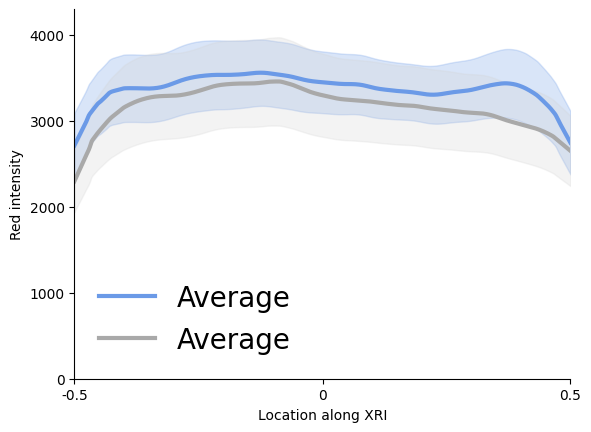

In [ ]:
red = '#cc493e'
blue = '#6b9ae7'
    
plt.plot(average_drug, color=blue, linewidth=3, label='Average')
plt.fill_between(range(len(average_drug)), average_drug - stderr_drug, average_drug + stderr_drug, color=blue, alpha=0.25)

plt.plot(average_con, color='darkgray', linewidth=3, label='Average')
plt.fill_between(range(len(average_con)), average_con - stderr_con, average_con + stderr_con, color='lightgrey', alpha=0.25)




plt.xticks([0, len(average)//2, len(average)-1], [-0.5, 0, 0.5])

plt.xlim(0, len(average)-1)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ylim(0, 4300)
plt.yticks([0, 1000, 2000, 3000, 4000])

plt.xlabel("Location along XRI")
plt.ylabel("Red intensity")
plt.legend(frameon=False, fontsize=20)
plt.savefig('output.png')

plt.show()